In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [28]:
df_original = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

df_original.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [29]:
print(df_original.columns.tolist())

['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']


In [30]:
df_original["Sleep Disorder"] = df_original["Sleep Disorder"].fillna("No Disorder")

In [31]:
df = df_original.drop(columns=["Person ID"])

In [32]:
df[['Systolic BP','Diastolic BP']] = df["Blood Pressure"].str.split("/", expand=True).astype(float)

df.drop(columns=["Blood Pressure"], inplace=True)

In [33]:
gender_mapping = {"Male":1,"Female":2}

bmi_mapping = {"Normal":1,"Overweight":2,"Obese":3}

df["Gender"] = df["Gender"].map(gender_mapping)

df["BMI Category"] = df["BMI Category"].map(bmi_mapping)

In [34]:
occupation_encoder = LabelEncoder()

df["Occupation"] = occupation_encoder.fit_transform(df["Occupation"])

In [35]:
le_disorder = LabelEncoder()

df["Sleep Disorder Numeric"] = le_disorder.fit_transform(df["Sleep Disorder"])

In [36]:
df.fillna(df.median(numeric_only=True), inplace=True)

df.fillna(df.mode().iloc[0], inplace=True)

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP,Sleep Disorder Numeric
0,1,27,9,6.1,6,42,6,2.0,77,4200,No Disorder,126.0,83.0,1
1,1,28,1,6.2,6,60,8,1.0,75,10000,No Disorder,125.0,80.0,1
2,1,28,1,6.2,6,60,8,1.0,75,10000,No Disorder,125.0,80.0,1
3,1,28,6,5.9,4,30,8,3.0,85,3000,Sleep Apnea,140.0,90.0,2
4,1,28,6,5.9,4,30,8,3.0,85,3000,Sleep Apnea,140.0,90.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,2,59,5,8.1,9,75,3,2.0,68,7000,Sleep Apnea,140.0,95.0,2
370,2,59,5,8.0,9,75,3,2.0,68,7000,Sleep Apnea,140.0,95.0,2
371,2,59,5,8.1,9,75,3,2.0,68,7000,Sleep Apnea,140.0,95.0,2
372,2,59,5,8.1,9,75,3,2.0,68,7000,Sleep Apnea,140.0,95.0,2


In [37]:
# Save preprocessed dataset BEFORE SMOTE
df.to_csv("Preprocessed_Sleep_Dataset.csv", index=False)

print("Preprocessed dataset saved successfully!")

Preprocessed dataset saved successfully!


In [38]:
X = df.drop(columns=["Sleep Disorder","Sleep Disorder Numeric"])

y = df["Sleep Disorder Numeric"]

smote = SMOTE(random_state=42)

X_resampled,y_resampled = smote.fit_resample(X,y)

In [39]:
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)

df_resampled["Sleep Disorder"] = le_disorder.inverse_transform(y_resampled)

df_resampled.to_csv("Cleaned_Sleep_Dataset.csv", index=False)

print("Dataset cleaned and saved successfully")

Dataset cleaned and saved successfully


In [40]:
df = pd.read_csv("Cleaned_Sleep_Dataset.csv")

In [41]:
df["Sleep Disorder"] = df["Sleep Disorder"].map({
"No Disorder":0,
"Sleep Apnea":1,
"Insomnia":2
})

In [42]:
X = df.drop("Sleep Disorder",axis=1)

y = df["Sleep Disorder"]

In [43]:
X_train,X_test,y_train,y_test = train_test_split(
X,y,test_size=0.2,random_state=42
)

In [44]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [45]:
models = {

"Logistic Regression": LogisticRegression(),

"Decision Tree": DecisionTreeClassifier(),

"Random Forest": RandomForestClassifier(),

"SVM": SVC(probability=True),

"KNN": KNeighborsClassifier(),

"XGBoost": XGBClassifier()

}

In [46]:
best_model=None
best_accuracy=0
model_accuracies={}

for name,model in models.items():
    
    model.fit(X_train,y_train)
    
    y_pred=model.predict(X_test)
    
    acc=accuracy_score(y_test,y_pred)
    
    model_accuracies[name]=acc
    
    print(name,"Accuracy:",round(acc,2))
    
    print(classification_report(y_test,y_pred))
    
    if acc>best_accuracy:
        best_accuracy=acc
        best_model=model

Logistic Regression Accuracy: 0.88
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        52
           1       0.91      0.84      0.88        51
           2       0.76      0.86      0.81        29

    accuracy                           0.88       132
   macro avg       0.87      0.88      0.87       132
weighted avg       0.88      0.88      0.88       132

Decision Tree Accuracy: 0.92
              precision    recall  f1-score   support

           0       0.94      0.96      0.95        52
           1       0.94      0.92      0.93        51
           2       0.86      0.86      0.86        29

    accuracy                           0.92       132
   macro avg       0.92      0.92      0.92       132
weighted avg       0.92      0.92      0.92       132

Random Forest Accuracy: 0.93
              precision    recall  f1-score   support

           0       0.94      0.96      0.95        52
           1       0.94      0.94   

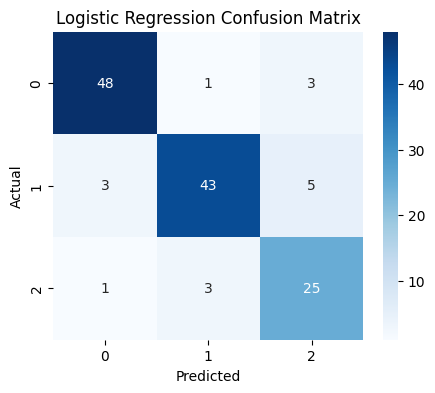

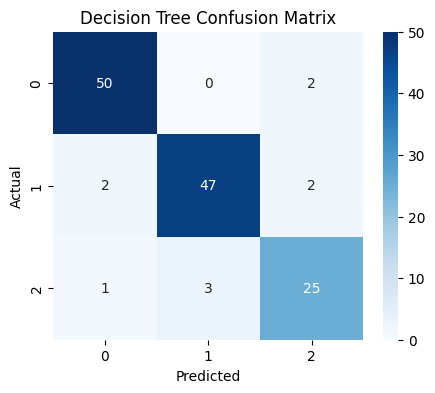

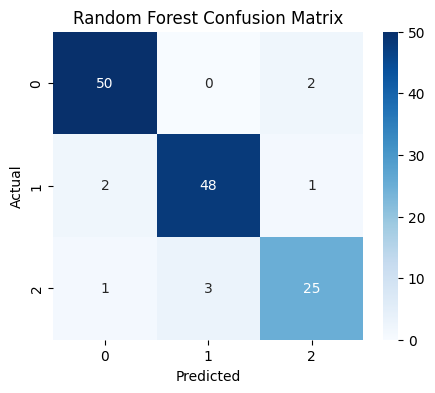

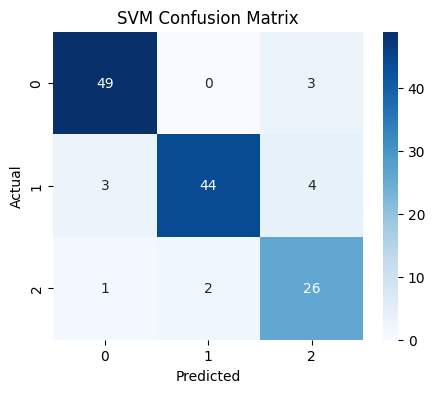

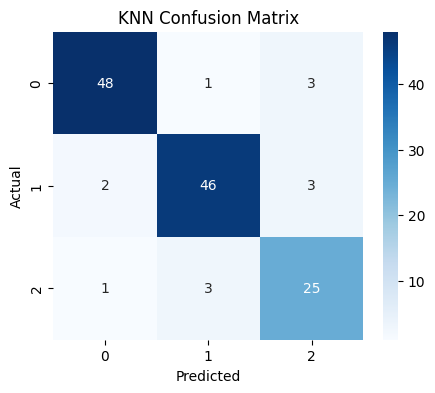

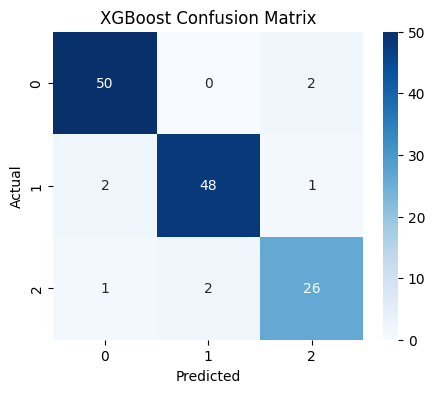

In [47]:
for name,model in models.items():

    y_pred=model.predict(X_test)

    cm=confusion_matrix(y_test,y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

    plt.title(name+" Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

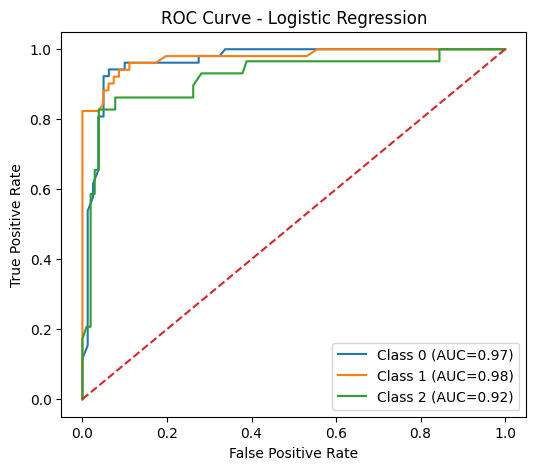

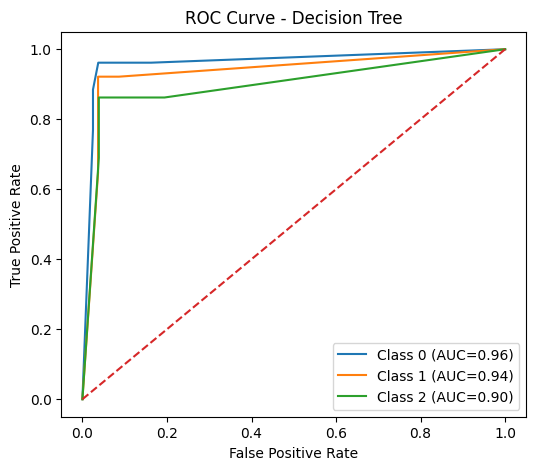

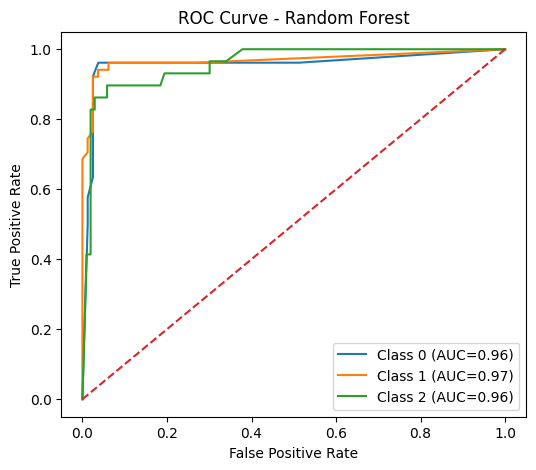

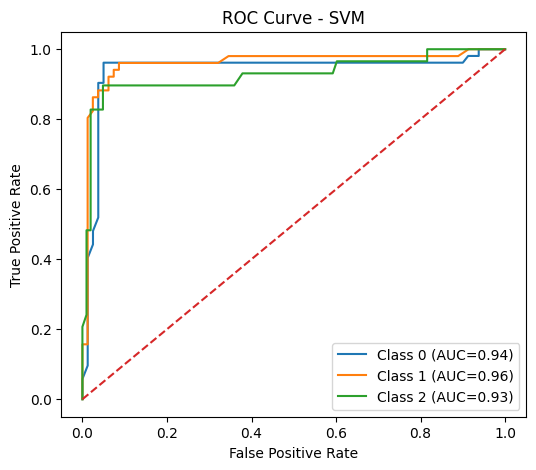

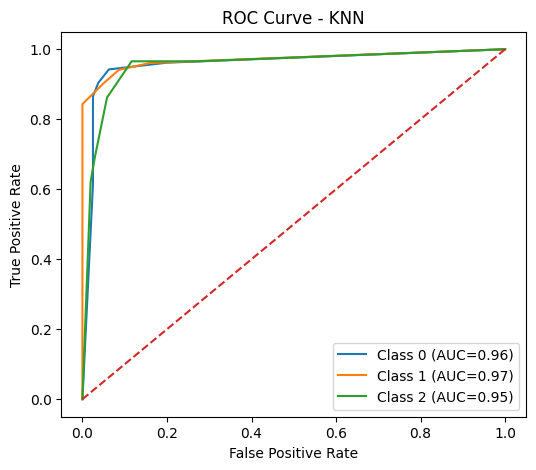

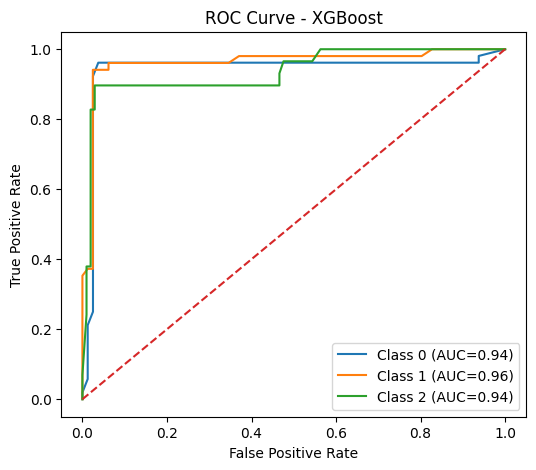

In [48]:
y_test_bin = label_binarize(y_test,classes=[0,1,2])

for name,model in models.items():

    y_score=model.predict_proba(X_test)

    plt.figure(figsize=(6,5))

    for i in range(3):

        fpr,tpr,_=roc_curve(y_test_bin[:,i],y_score[:,i])

        roc_auc=auc(fpr,tpr)

        plt.plot(fpr,tpr,label=f"Class {i} (AUC={roc_auc:.2f})")

    plt.plot([0,1],[0,1],'--')

    plt.title("ROC Curve - "+name)

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.legend()

    plt.show()

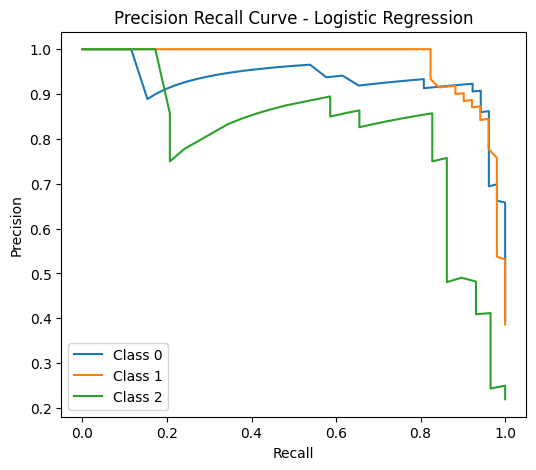

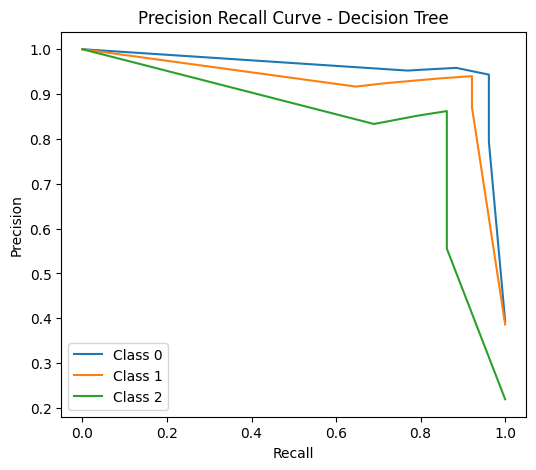

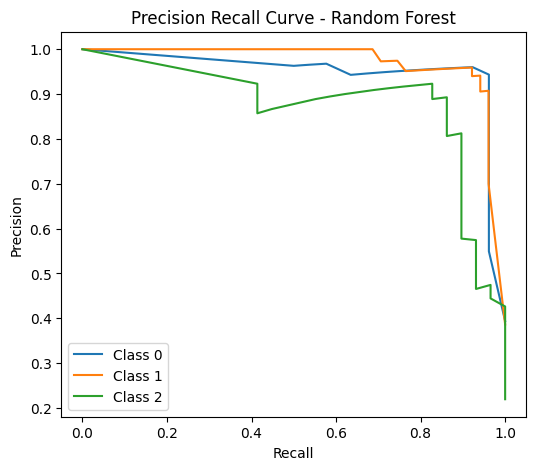

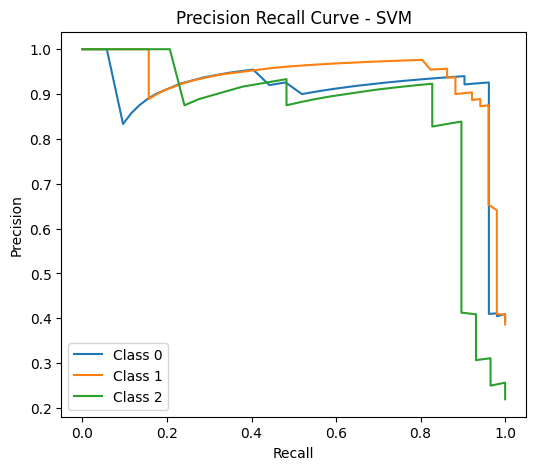

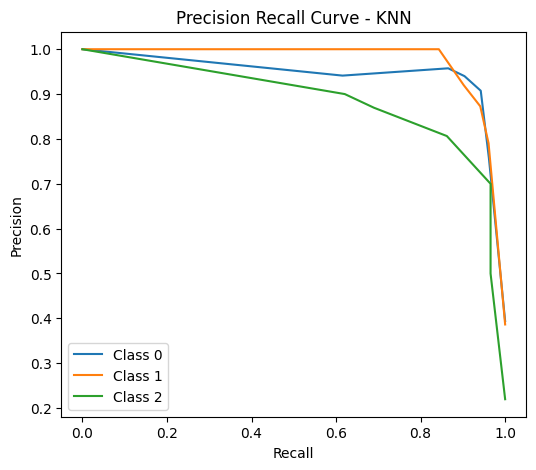

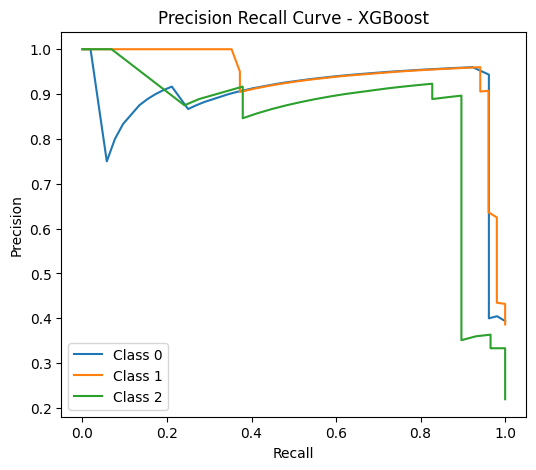

In [49]:
for name,model in models.items():

    y_score=model.predict_proba(X_test)

    plt.figure(figsize=(6,5))

    for i in range(3):

        precision,recall,_ = precision_recall_curve(y_test_bin[:,i],y_score[:,i])

        plt.plot(recall,precision,label=f"Class {i}")

    plt.xlabel("Recall")

    plt.ylabel("Precision")

    plt.title("Precision Recall Curve - "+name)

    plt.legend()

    plt.show()

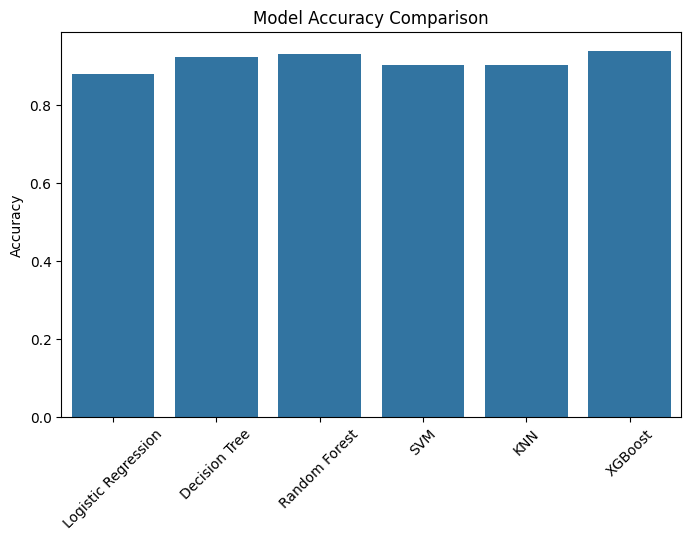

In [50]:
plt.figure(figsize=(8,5))

sns.barplot(
x=list(model_accuracies.keys()),
y=list(model_accuracies.values())
)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.show()

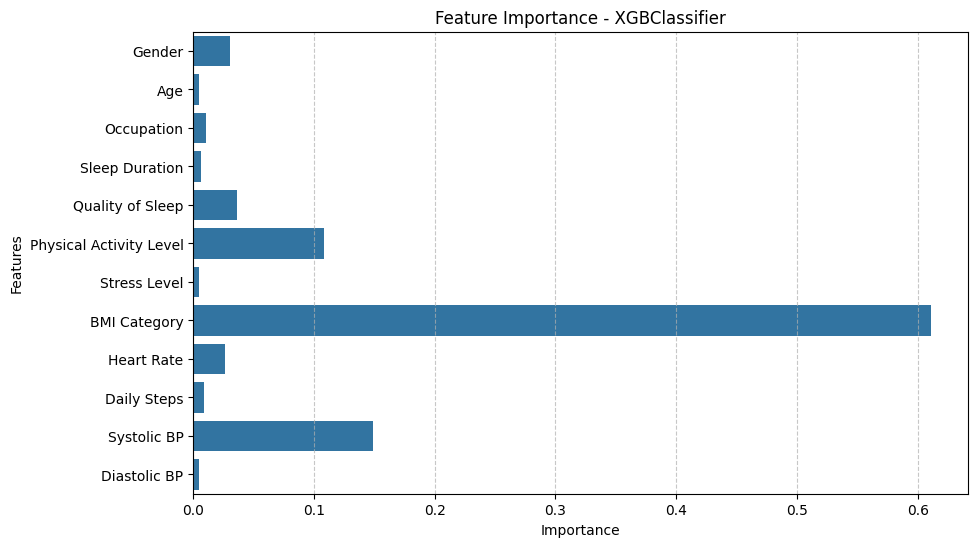

In [51]:
# Feature Importance Plot

if hasattr(best_model, "feature_importances_"):
    
    importances = best_model.feature_importances_
    feature_names = X.columns

    plt.figure(figsize=(10,6))

    sns.barplot(x=importances, y=feature_names)

    plt.title(f"Feature Importance - {type(best_model).__name__}")

    plt.xlabel("Importance")
    plt.ylabel("Features")

    plt.grid(axis="x", linestyle="--", alpha=0.7)

    plt.show()

else:
    print("This model does not support feature importance.")

In [52]:
import joblib

joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully")

Model and scaler saved successfully
